In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler



In [ ]:
df= pd.read_csv('thyroid_dataset.csv')

In [11]:
df.head()
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   int64  
 2   on_thyroxine               6916 non-null   int64  
 3   query_on_thyroxine         6916 non-null   int64  
 4   on_antithyroid_medication  6916 non-null   int64  
 5   sick                       6916 non-null   int64  
 6   pregnant                   6916 non-null   int64  
 7   thyroid_surgery            6916 non-null   int64  
 8   I131_treatment             6916 non-null   int64  
 9   query_hypothyroid          6916 non-null   int64  
 10  query_hyperthyroid         6916 non-null   int64  
 11  lithium                    6916 non-null   int64  
 12  goitre                     6916 non-null   int64  
 13  tumor                      6916 non-null   int64

(6916, 22)

In [14]:
X= df.drop("Outlier_label", axis=1)
y= df["Outlier_label"]

In [17]:
sc=StandardScaler()
x_scaled=sc.fit_transform(X)

In [18]:
from sklearn.ensemble import IsolationForest

isf=IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
    
    
) 

In [19]:
labels=isf.fit_predict(x_scaled)

In [20]:
# Visulize 

# we can use dimensionality reduction by PCA

from sklearn.decomposition import PCA

pca= PCA(n_components=2)

x_pca= pca.fit_transform(x_scaled)




Text(0, 0.5, 'PCA-2')

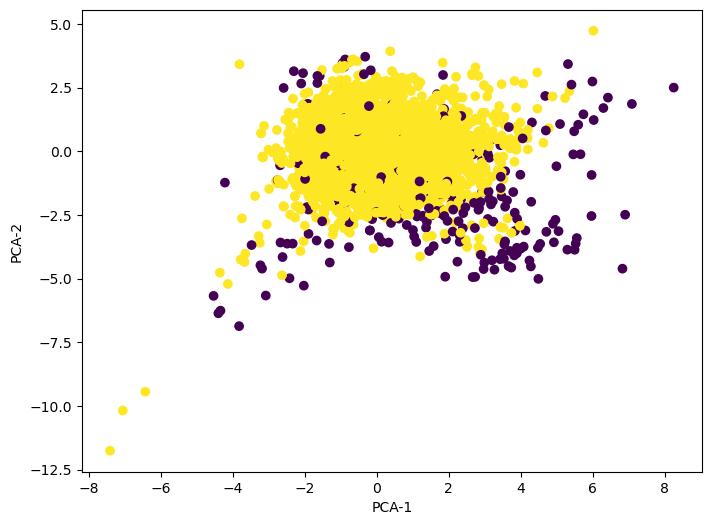

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")



In [23]:
import numpy as np

n_outliers=np.sum(labels==-1)

normal_points=np.sum(labels==1)
print(f"No of outliers :{n_outliers}")
print(f"No of Normal points {normal_points}")

No of outliers :270
No of Normal points 6646


No of outliers :249
No of Normal points 6667


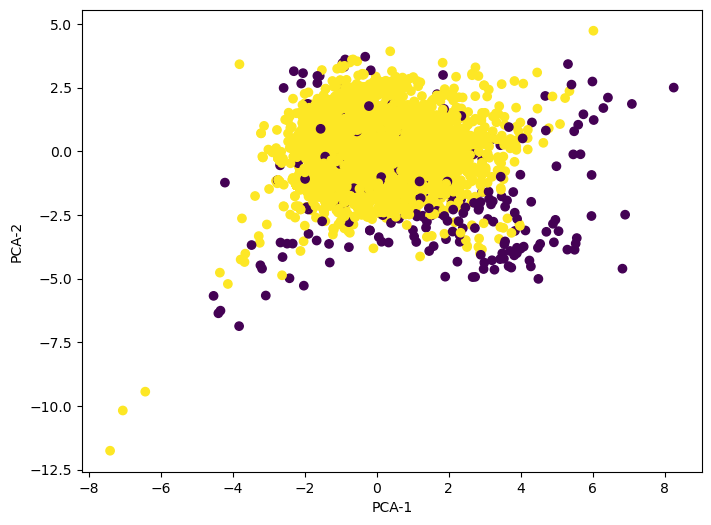

In [25]:
# we can give the percenteage

isf=IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42
    
    
) 

labels=isf.fit_predict(x_scaled)

pca= PCA(n_components=2)

x_pca= pca.fit_transform(x_scaled)


plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")

n_outliers=np.sum(labels==-1)

normal_points=np.sum(labels==1)
print(f"No of outliers :{n_outliers}")
print(f"No of Normal points {normal_points}")
